# Discussion 5 Assignment

Alexander Zhang  
alexacz1@uci.edu

## Setup  
Load dependencies and set up environment for discussion 5.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%pip install ucimlrepo
from ucimlrepo import fetch_ucirepo 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set_theme(style="whitegrid", palette="muted")

print("Fetching HCV Egyptian Patients dataset...")

hcv_dataset = fetch_ucirepo(id=503) 

X = hcv_dataset.data.features 
y = hcv_dataset.data.targets

y = y.iloc[:, 0]

print(f"Dataset successfully loaded via ucimlrepo!")
print(f"Total Patients: {X.shape[0]}")
print(f"Total Features: {X.shape[1]}")
print(f"Features included: {X.columns.tolist()[:5]} ... and more.")

Note: you may need to restart the kernel to use updated packages.
Fetching HCV Egyptian Patients dataset from UCI (ID: 503)...
Dataset successfully loaded via ucimlrepo!
Total Patients: 1385
Total Features: 28
Features included: ['Age ', 'Gender', 'BMI', 'Fever', 'Nausea/Vomting'] ... and more.


## Summarization & Visualization
In HCV staging, it is important to see if the stages (F1-F4) are balanced and how age or BMI might relate to liver health. Two plots will be made to show this: a target class balance graph and correlation plot.


--- DATA SUMMARIZATION ---
Distribution of Fibrosis Stages:
Baselinehistological staging
1    336
2    332
3    355
4    362
Name: count, dtype: int64


/var/folders/k8/p0zmwvf53y155yg14pkmym6w0000gp/T/ipykernel_10720/1743696638.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


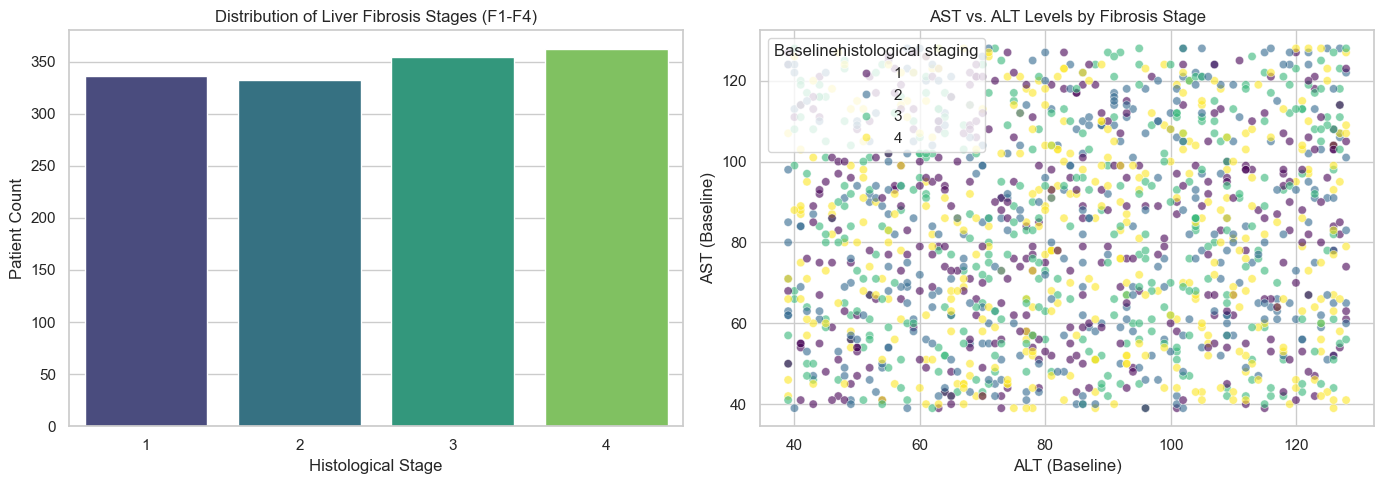

In [4]:
print("\n--- DATA SUMMARIZATION ---")

print("Distribution of Fibrosis Stages:")
print(y.value_counts().sort_index())

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y, palette='viridis')
plt.title("Distribution of Liver Fibrosis Stages (F1-F4)")
plt.xlabel("Histological Stage")
plt.ylabel("Patient Count")

plt.subplot(1, 2, 2)
sns.scatterplot(x=X['ALT 1'], y=X['AST 1'], hue=y, palette='viridis', alpha=0.6)
plt.title("AST vs. ALT Levels by Fibrosis Stage")
plt.xlabel("ALT (Baseline)")
plt.ylabel("AST (Baseline)")

plt.tight_layout()
plt.show()

## Preprocessing & Scaling

The data must be scaled so the model doesn't think features like RNA Base are more important just because the numbers are bigger. An 80-20 training-test split will be utilized.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data successfully split and scaled.")
print(f"Training set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples")

Data successfully split and scaled.
Training set: 1108 samples | Test set: 277 samples
